# Исходные данные

In [1]:
from pathlib import Path
import sqlite3

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
pd.options.display.max_columns = 100
pd.options.display.float_format = lambda x: f'{x:,.2f}'.replace(',', ' ')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

HERE = Path.cwd().resolve()
if (HERE / 'backend').exists():
    ROOT = HERE
elif (HERE.parent / 'backend').exists():
    ROOT = HERE.parent
else:
    ROOT = Path('/Users/sergey/PycharmProjects/WB_hackaton')

DATA_DIR = ROOT / 'backend' / 'data'
TRASH_DIR = ROOT / 'trash'
TARGET_COL = 'target_2h'
RANDOM_STATE = 42
EDA_SAMPLE_N = 150_000

## Загрузка

In [2]:
train_df = pd.read_parquet(DATA_DIR / 'train_team_track.parquet')
test_df = pd.read_parquet(DATA_DIR / 'test_team_track.parquet')
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])
test_df['timestamp'] = pd.to_datetime(test_df['timestamp'])
STATUS_COLS = sorted([c for c in train_df.columns if c.startswith('status_')])

con = sqlite3.connect(DATA_DIR / 'app.db')
warehouses_df = pd.read_sql_query('select * from warehouses', con)
routes_df = pd.read_sql_query('select * from routes', con)
vehicle_types_df = pd.read_sql_query('select * from vehicle_types', con)
con.close()

In [3]:
print('строк train', f"{len(train_df):,}".replace(',', ' '))
print('строк test', f"{len(test_df):,}".replace(',', ' '))
print('маршрутов train', train_df['route_id'].nunique())
print('складов', warehouses_df['id'].nunique())
print('типов ТС', vehicle_types_df['vehicle_type'].nunique())

строк train 4 342 000
строк test 10 000
маршрутов train 1000
складов 86
типов ТС 6


In [4]:
summary_df = pd.DataFrame([
    {'метрика': 'train start', 'значение': train_df['timestamp'].min()},
    {'метрика': 'train end', 'значение': train_df['timestamp'].max()},
    {'метрика': 'test start', 'значение': test_df['timestamp'].min()},
    {'метрика': 'test end', 'значение': test_df['timestamp'].max()},
    {'метрика': 'route_id train', 'значение': train_df['route_id'].nunique()},
    {'метрика': 'route_id test', 'значение': test_df['route_id'].nunique()},
])
display(summary_df)

,метрика,значение
0,train start,2025-03-01 00:00:00
1,train end,2025-05-30 10:30:00
2,test start,2025-05-30 11:00:00
3,test end,2025-05-30 15:30:00
4,route_id train,1000
5,route_id test,1000


## Схема

In [5]:
schema_df = pd.DataFrame({
    'col': train_df.columns,
    'dtype': train_df.dtypes.astype(str).values,
    'na_pct': train_df.isna().mean().mul(100).round(2).values,
    'nunique': [train_df[c].nunique(dropna=False) for c in train_df.columns],
})
display(schema_df)

,col,dtype,na_pct,nunique
0,office_from_id,int64,0.00,53
1,route_id,int64,0.00,1000
2,timestamp,datetime64[ns],0.00,4342
3,status_1,int64,0.00,19752
4,status_2,int64,0.00,2127
5,status_3,int64,0.00,17998
6,status_4,int64,0.00,14416
7,status_5,int64,0.00,17108
8,status_6,int64,0.00,17616
9,status_7,int64,0.00,38219


## Время

In [6]:
step_df = (
    train_df.sort_values(['route_id', 'timestamp'])
    .groupby('route_id')['timestamp']
    .diff()
    .dropna()
    .dt.total_seconds()
    .div(60)
    .value_counts()
    .sort_index()
    .rename_axis('шаг_мин')
    .reset_index(name='строк')
)
display(step_df)

,шаг_мин,строк
0,30.00,4341000


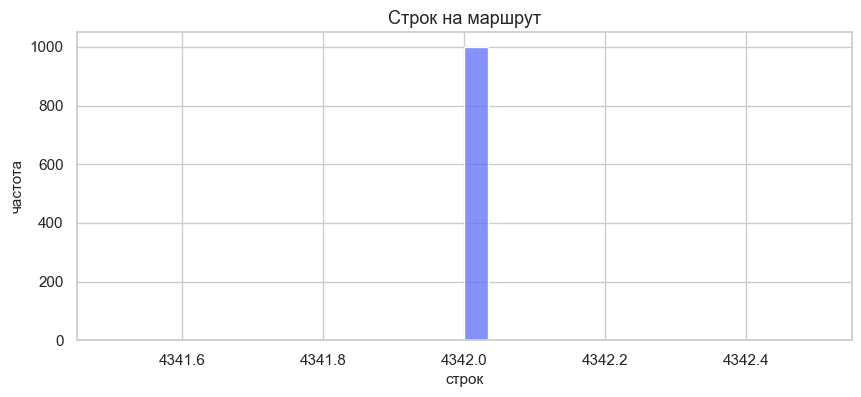

In [7]:
rows_per_route = train_df.groupby('route_id').size()
plt.figure(figsize=(10, 4))
sns.histplot(rows_per_route, bins=30, color='#5B6CFF')
plt.title('Строк на маршрут')
plt.xlabel('строк')
plt.ylabel('частота')
plt.show()

## target_2h

In [8]:
target_stats = train_df[TARGET_COL].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame('target_2h')
display(target_stats)

,target_2h
count,4 342 000.00
mean,68.75
std,67.49
min,0.00
50%,48.00
75%,100.00
90%,157.00
95%,196.00
99%,293.00
max,1 517.00


In [9]:
sample_df = train_df.sample(min(EDA_SAMPLE_N, len(train_df)), random_state=RANDOM_STATE).copy()

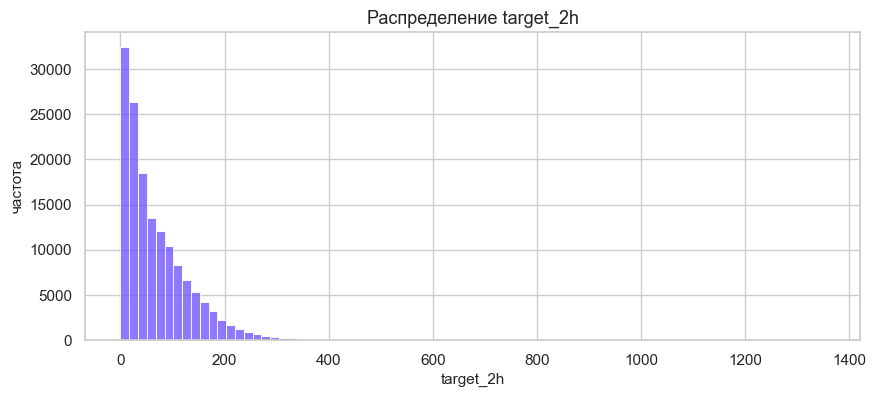

In [10]:
plt.figure(figsize=(10, 4))
sns.histplot(sample_df[TARGET_COL], bins=80, color='#6A4CFF')
plt.title('Распределение target_2h')
plt.xlabel('target_2h')
plt.ylabel('частота')
plt.show()

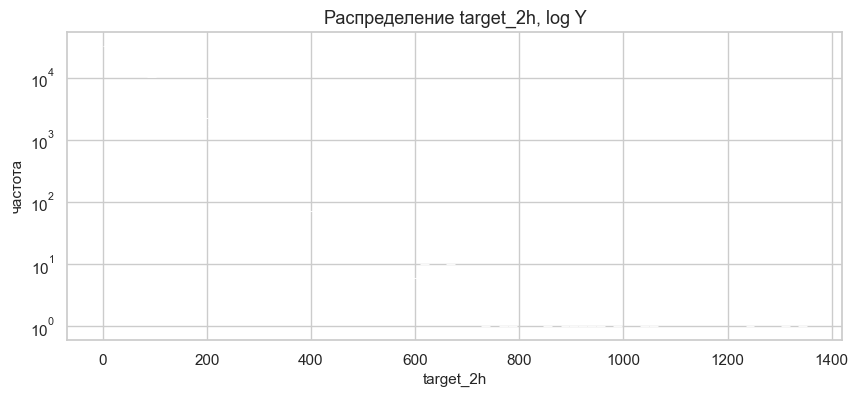

In [11]:
plt.figure(figsize=(10, 4))
sns.histplot(sample_df[TARGET_COL], bins=80, color='#FF9F1C', log_scale=(False, True))
plt.title('Распределение target_2h, log Y')
plt.xlabel('target_2h')
plt.ylabel('частота')
plt.show()

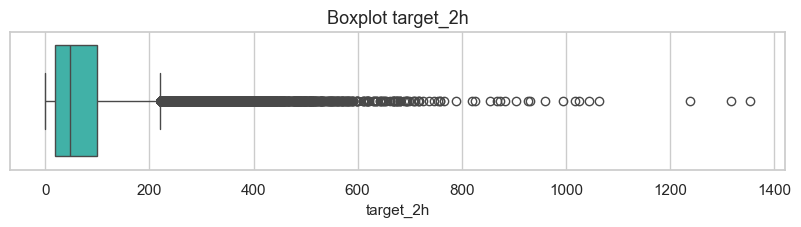

In [12]:
plt.figure(figsize=(10, 1.8))
sns.boxplot(x=sample_df[TARGET_COL], color='#2EC4B6')
plt.title('Boxplot target_2h')
plt.xlabel('target_2h')
plt.show()

## Сезонность

In [13]:
train_df['hour'] = train_df['timestamp'].dt.hour
train_df['weekday'] = train_df['timestamp'].dt.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

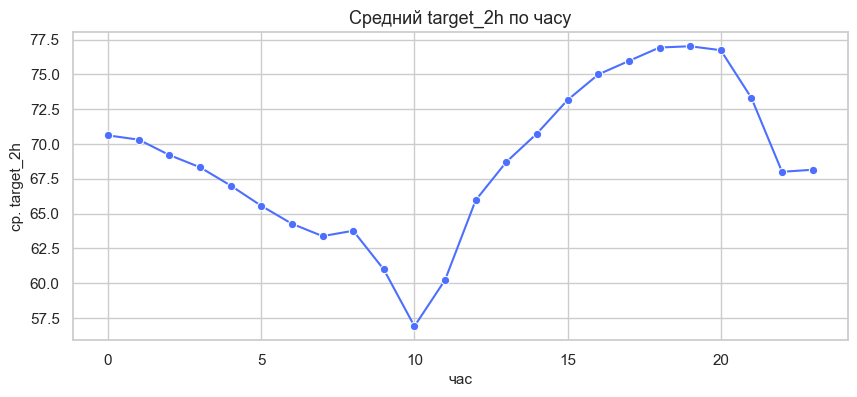

In [14]:
hour_target = train_df.groupby('hour')[TARGET_COL].mean().reset_index(name='mean_target')
plt.figure(figsize=(10, 4))
sns.lineplot(data=hour_target, x='hour', y='mean_target', marker='o', color='#4C6FFF')
plt.title('Средний target_2h по часу')
plt.xlabel('час')
plt.ylabel('ср. target_2h')
plt.show()

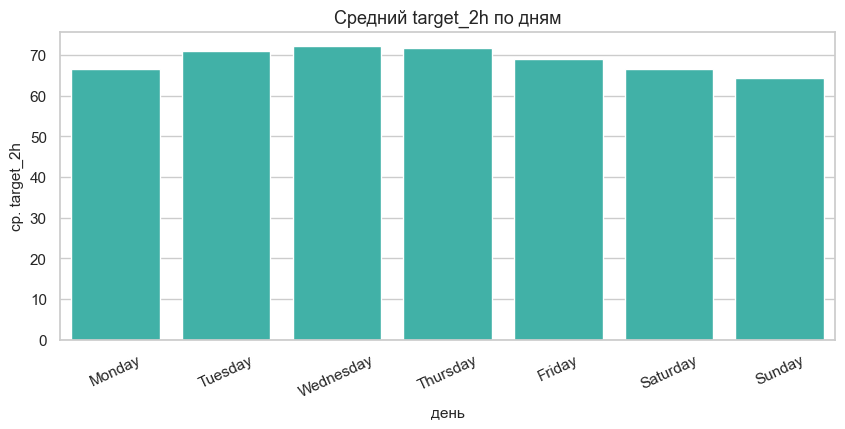

In [15]:
weekday_target = (
    train_df.groupby('weekday')[TARGET_COL]
    .mean()
    .reindex(weekday_order)
    .reset_index(name='mean_target')
)
plt.figure(figsize=(10, 4))
sns.barplot(data=weekday_target, x='weekday', y='mean_target', color='#2EC4B6')
plt.title('Средний target_2h по дням')
plt.xlabel('день')
plt.ylabel('ср. target_2h')
plt.xticks(rotation=25)
plt.show()

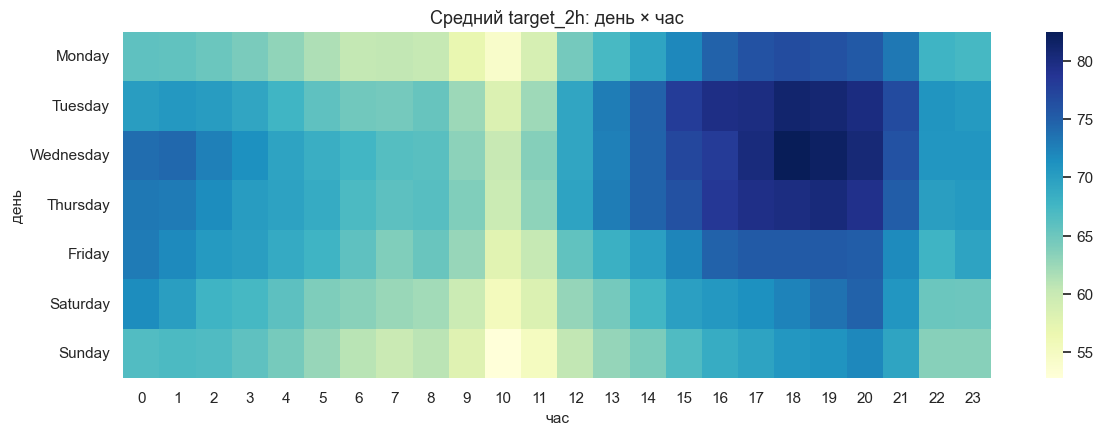

In [16]:
hour_weekday = (
    train_df.groupby(['weekday', 'hour'])[TARGET_COL]
    .mean()
    .reset_index()
)
hour_weekday_pivot = hour_weekday.pivot(index='weekday', columns='hour', values=TARGET_COL).reindex(weekday_order)

plt.figure(figsize=(14, 4.5))
sns.heatmap(hour_weekday_pivot, cmap='YlGnBu', annot=False)
plt.title('Средний target_2h: день × час')
plt.xlabel('час')
plt.ylabel('день')
plt.show()

## Будущие таргеты

In [17]:
for step in range(1, 13):
    col = f'target_step_{step}'
    if col not in train_df.columns:
        train_df[col] = train_df.groupby('route_id', sort=False)[TARGET_COL].shift(-step)

In [18]:
preview_cols = ['route_id', 'timestamp', TARGET_COL, 'target_step_4', 'target_step_8', 'target_step_12']
display(train_df[preview_cols].head(12))

,route_id,timestamp,target_2h,target_step_4,target_step_8,target_step_12
0,29,2025-03-01 00:00:00,27.00,31.00,30.00,26.00
1,29,2025-03-01 00:30:00,27.00,37.00,25.00,26.00
2,29,2025-03-01 01:00:00,23.00,41.00,30.00,24.00
3,29,2025-03-01 01:30:00,37.00,27.00,27.00,22.00
4,29,2025-03-01 02:00:00,31.00,30.00,26.00,23.00
5,29,2025-03-01 02:30:00,37.00,25.00,26.00,20.00
6,29,2025-03-01 03:00:00,41.00,30.00,24.00,12.00
7,29,2025-03-01 03:30:00,27.00,27.00,22.00,12.00
8,29,2025-03-01 04:00:00,30.00,26.00,23.00,6.00
9,29,2025-03-01 04:30:00,25.00,26.00,20.00,7.00


In [19]:
coverage_df = pd.DataFrame([
    {
        'target': f'target_step_{step}',
        'непустых': int(train_df[f'target_step_{step}'].notna().sum()),
        'coverage_pct': round(train_df[f'target_step_{step}'].notna().mean() * 100, 2),
    }
    for step in range(1, 13)
])
display(coverage_df)

,target,непустых,coverage_pct
0,target_step_1,4341000,99.98
1,target_step_2,4340000,99.95
2,target_step_3,4339000,99.93
3,target_step_4,4338000,99.91
4,target_step_5,4337000,99.88
5,target_step_6,4336000,99.86
6,target_step_7,4335000,99.84
7,target_step_8,4334000,99.82
8,target_step_9,4333000,99.79
9,target_step_10,4332000,99.77


## Связи

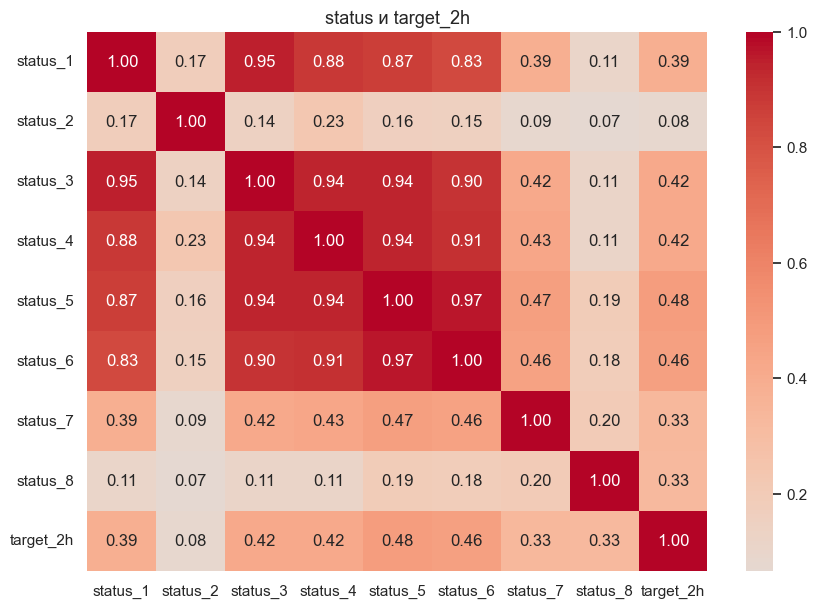

In [20]:
corr_current_df = sample_df[STATUS_COLS + [TARGET_COL]].corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr_current_df, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('status и target_2h')
plt.show()

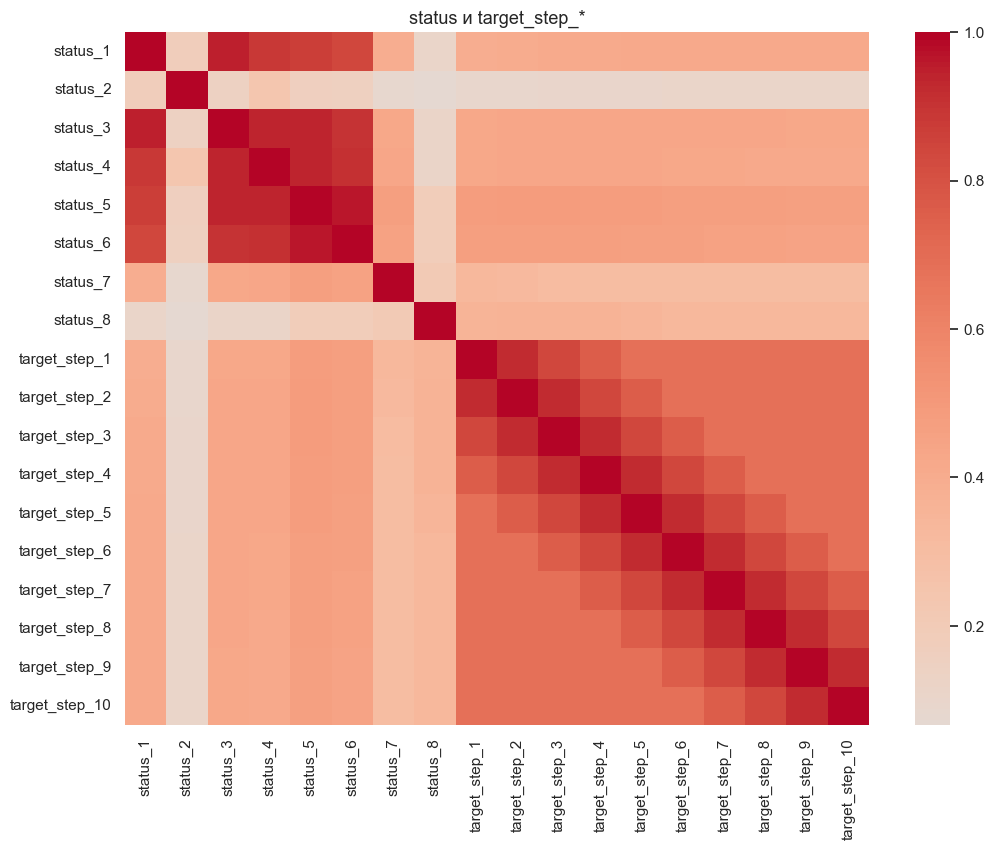

In [21]:
baseline_target_cols = [f'target_step_{step}' for step in range(1, 11)]
supervised_df = train_df.dropna(subset=baseline_target_cols).copy()
heatmap_df = supervised_df[STATUS_COLS + baseline_target_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(heatmap_df, annot=False, cmap='coolwarm', center=0)
plt.title('status и target_step_*')
plt.show()

In [22]:
horizon_signal_df = pd.DataFrame([
    {
        'step': step,
        'hours_ahead': step * 0.5,
        'corr': train_df[[TARGET_COL, f'target_step_{step}']].dropna().corr(numeric_only=True).iloc[0, 1],
        'mae_shift': (train_df[f'target_step_{step}'] - train_df[TARGET_COL]).abs().mean(),
    }
    for step in range(1, 13)
])
display(horizon_signal_df)

,step,hours_ahead,corr,mae_shift
0,1,0.50,0.92,12.83
1,2,1.00,0.84,19.52
2,3,1.50,0.76,24.58
3,4,2.00,0.68,28.72
4,5,2.50,0.68,28.62
5,6,3.00,0.68,28.54
6,7,3.50,0.68,28.59
7,8,4.00,0.68,28.75
8,9,4.50,0.68,28.99
9,10,5.00,0.68,29.25


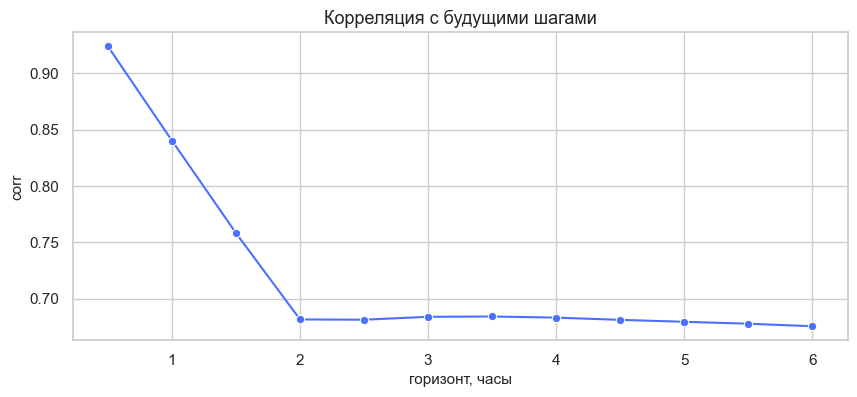

In [23]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=horizon_signal_df, x='hours_ahead', y='corr', marker='o', color='#4C6FFF')
plt.title('Корреляция с будущими шагами')
plt.xlabel('горизонт, часы')
plt.ylabel('corr')
plt.show()

In [24]:
ml_feature_df = supervised_df.copy()
ml_feature_df['hour'] = ml_feature_df['timestamp'].dt.hour
ml_feature_df['weekday_num'] = ml_feature_df['timestamp'].dt.weekday
ml_feature_df['hour_sin'] = np.sin(2 * np.pi * ml_feature_df['hour'] / 24)
ml_feature_df['hour_cos'] = np.cos(2 * np.pi * ml_feature_df['hour'] / 24)
ml_feature_df['weekday_sin'] = np.sin(2 * np.pi * ml_feature_df['weekday_num'] / 7)
ml_feature_df['weekday_cos'] = np.cos(2 * np.pi * ml_feature_df['weekday_num'] / 7)

feature_cols = [TARGET_COL] + STATUS_COLS + ['hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos']
feature_signal_df = (
    ml_feature_df[feature_cols + ['target_step_4']]
    .corr(numeric_only=True)['target_step_4']
    .drop('target_step_4')
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .rename('corr')
    .reset_index()
    .rename(columns={'index': 'feature'})
)
display(feature_signal_df)

,feature,corr
0,target_2h,0.68
1,status_5,0.48
2,status_6,0.47
3,status_3,0.44
4,status_4,0.43
5,status_1,0.41
6,status_8,0.36
7,status_7,0.30
8,status_2,0.10
9,hour_sin,-0.07


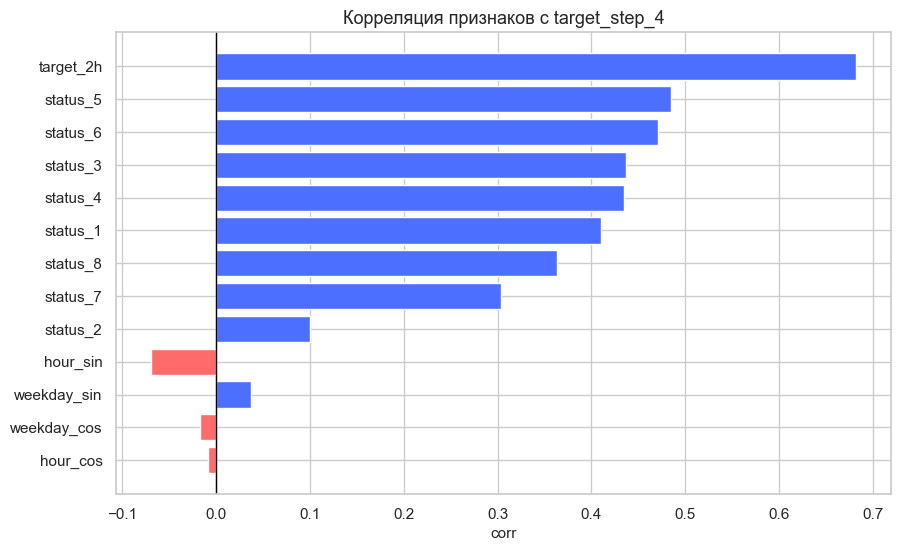

In [25]:
colors = ['#4C6FFF' if v >= 0 else '#FF6B6B' for v in feature_signal_df['corr']]
plt.figure(figsize=(10, 6))
plt.barh(feature_signal_df['feature'], feature_signal_df['corr'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.gca().invert_yaxis()
plt.title('Корреляция признаков с target_step_4')
plt.xlabel('corr')
plt.ylabel('')
plt.show()

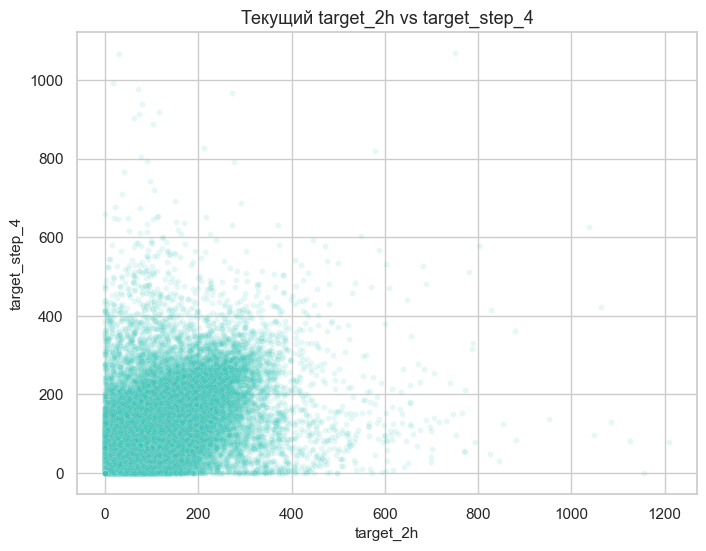

In [26]:
future_sample_df = train_df.dropna(subset=['target_step_4']).sample(
    min(EDA_SAMPLE_N, train_df['target_step_4'].notna().sum()),
    random_state=RANDOM_STATE,
)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=future_sample_df, x=TARGET_COL, y='target_step_4', alpha=0.12, s=18, color='#2EC4B6')
plt.title('Текущий target_2h vs target_step_4')
plt.xlabel('target_2h')
plt.ylabel('target_step_4')
plt.show()

## Маршруты и склады

In [27]:
route_profile_df = (
    train_df.groupby('route_id')[TARGET_COL]
    .agg(mean_target='mean', std_target='std', cnt='size')
    .reset_index()
)
route_profile_df['cv'] = route_profile_df['std_target'] / route_profile_df['mean_target'].replace(0, np.nan)
display(route_profile_df.sort_values('cv', ascending=False).head(15))

,route_id,mean_target,std_target,cnt,cv
304,304,3.91,23.88,4342,6.11
811,811,6.40,35.57,4342,5.56
518,518,10.14,49.33,4342,4.86
609,609,11.99,57.05,4342,4.76
193,193,11.21,38.40,4342,3.43
589,589,11.14,36.07,4342,3.24
431,431,18.73,50.84,4342,2.71
936,936,38.88,77.29,4342,1.99
577,577,21.74,42.64,4342,1.96
912,912,22.10,42.62,4342,1.93


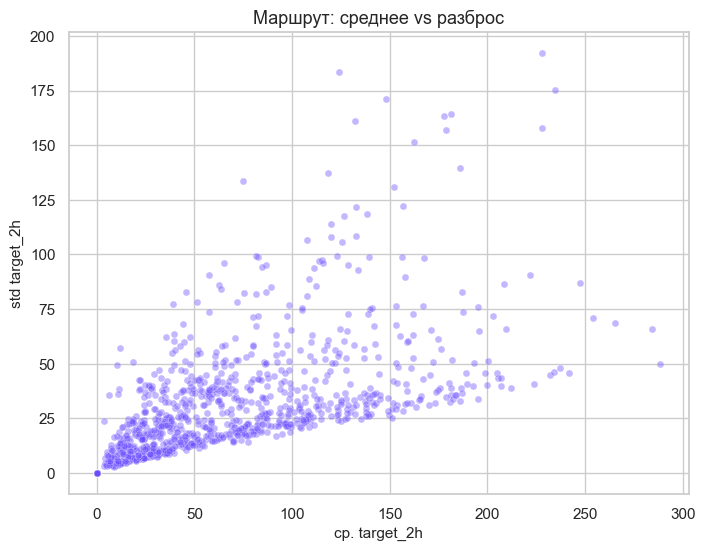

In [28]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=route_profile_df, x='mean_target', y='std_target', alpha=0.4, s=25, color='#6A4CFF')
plt.title('Маршрут: среднее vs разброс')
plt.xlabel('ср. target_2h')
plt.ylabel('std target_2h')
plt.show()

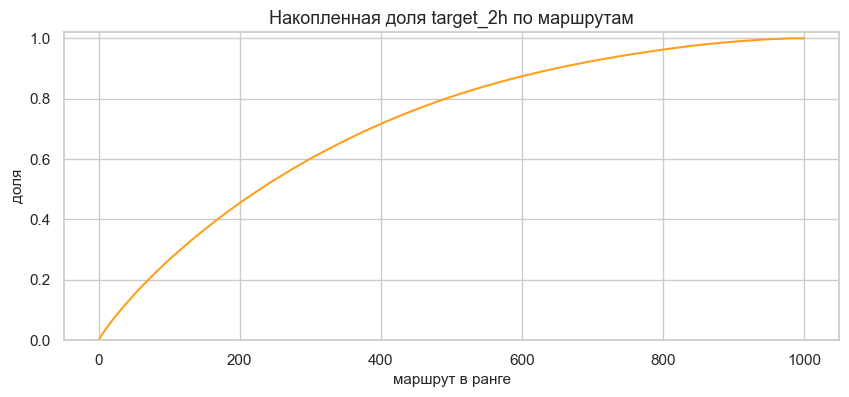

In [29]:
route_sum = train_df.groupby('route_id')[TARGET_COL].sum().sort_values(ascending=False)
cum_share_df = route_sum.reset_index(name='target_sum')
cum_share_df['rank'] = np.arange(1, len(cum_share_df) + 1)
cum_share_df['cum_share'] = cum_share_df['target_sum'].cumsum() / cum_share_df['target_sum'].sum()

plt.figure(figsize=(10, 4))
sns.lineplot(data=cum_share_df, x='rank', y='cum_share', color='#FF9F1C')
plt.title('Накопленная доля target_2h по маршрутам')
plt.xlabel('маршрут в ранге')
plt.ylabel('доля')
plt.ylim(0, 1.02)
plt.show()

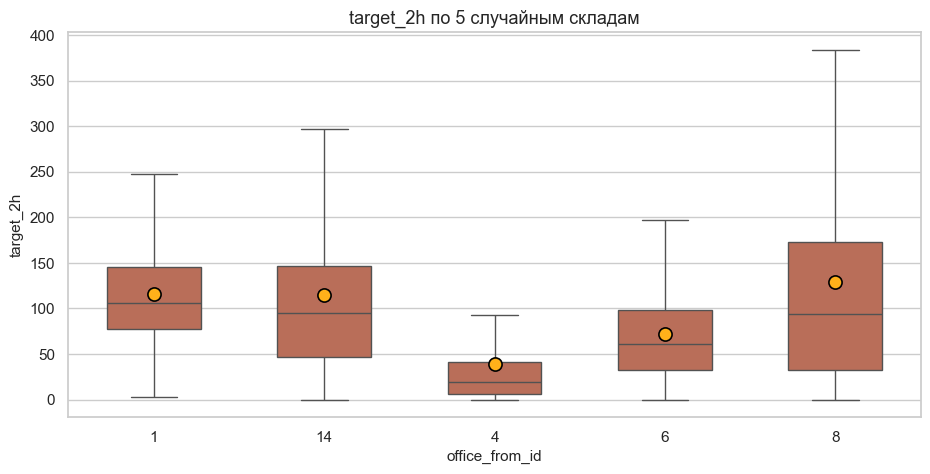

In [30]:
warehouse_target_df = train_df[['office_from_id', TARGET_COL]].copy()
warehouse_target_df['office_from_id'] = warehouse_target_df['office_from_id'].astype(str)
warehouses_df['office_from_id'] = warehouses_df['office_from_id'].astype(str)

eligible_wh = (
    warehouse_target_df[['office_from_id']]
    .drop_duplicates()
    .merge(warehouses_df[['id', 'office_from_id']], on='office_from_id', how='left')
    .dropna(subset=['id'])
    .drop_duplicates()
    .sort_values('office_from_id')
)
selected_wh = eligible_wh.sample(min(5, len(eligible_wh)), random_state=RANDOM_STATE).sort_values('office_from_id')
plot_wh_df = warehouse_target_df[warehouse_target_df['office_from_id'].isin(selected_wh['office_from_id'])].copy()
order = selected_wh['office_from_id'].tolist()
mean_df = plot_wh_df.groupby('office_from_id', as_index=False)[TARGET_COL].mean()

plt.figure(figsize=(11, 5))
ax = sns.boxplot(data=plot_wh_df, x='office_from_id', y=TARGET_COL, order=order, color='#C96549', width=0.55, showfliers=False)
sns.scatterplot(data=mean_df, x='office_from_id', y=TARGET_COL, s=90, color='#FFB11A', edgecolor='black', linewidth=1.2, zorder=5)
ax.set_title('target_2h по 5 случайным складам')
ax.set_xlabel('office_from_id')
ax.set_ylabel('target_2h')
plt.show()